# **Project: English Accent Classification**
Authors:
- Gael **Sustaita**
- Benjamin **Muñiz**
- Victor **Hermosillo**

Course: Language Processing

Professor: Dr. Nigel **Ward**

## 1. **Project Overview**

### **Project Idea**
Our system is a machine learning pipeline that listens to English speech and figures out if the speaker has an American, British, Australian, or Indian accent.

### **Problem Statement**

Accents are a key part of human identity, but they can sometimes present challenges in media production or automated speech recognition. Before we can "modify" an accent, we must first be able to identify what makes an accent unique using quantifiable data.

### **Project Objectives**

- Process raw audio clips to ensure consistency by adjusting the sample rate, removing silence, and standardizing all clips to a fixed length of 3 seconds.
- Implement a "Dual-Path" feature extraction strategy comparing handcrafted acoustic features (MFCCs, pitch, energy) against high-dimensional neural embeddings (WavLM).
- Train classification models, including Logistic Regression and SVM, to produce the final accent prediction.
- Measure system performance using standard stats (Accuracy, Precision, Recall, and F1-Scores) and visualize confusion matrices.

## 2. Libraries used

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from transformers import WavLMModel
from dotenv import load_dotenv

import warnings
warnings.filterwarnings("ignore")

## 3. Load datasets

### Local version

In [3]:
TSV_PATH = "Datasets/en/train.tsv" 
AUDIO_FOLDER = "Datasets/en/clips/"

df = pd.read_csv(TSV_PATH, sep='\t')

print("LExact names of the most common accents:")
print(df['accents'].value_counts().head(10))

LExact names of the most common accents:
accents
United States English                                 287940
England English                                        90558
India and South Asia (India, Pakistan, Sri Lanka)      82898
Canadian English                                       58982
Non native speaker|German English                      52152
Australian English                                     35336
Southern African (South Africa, Zimbabwe, Namibia)     22304
Scottish English                                       13441
Northern Irish                                         10358
New Zealand English                                     6152
Name: count, dtype: int64


First, we define the global constants that will govern our audio processing pipeline. We also establish a mapping dictionary to cleanly convert Mozilla's long, descriptive accent names into simple, readable labels for our final visualizations.

In [4]:
# Constants for Audio Processing
TARGET_SR = 16000
AUDIO_DURATION = 3 
FIXED_LENGTH = TARGET_SR * AUDIO_DURATION 
SAMPLES_PER_ACCENT = 5000 

# Map Mozilla's database names to our simplified visualization labels
ACCENT_MAPPING = {
    "United States English": "American",
    "England English": "British",
    "Australian English": "Australian",
    "India and South Asia (India, Pakistan, Sri Lanka)": "Indian"
}

Instead of processing audio inside a massive loop, we isolate the logic for a single file. This function takes one `.mp3` path and pushes it through our strict standardization pipeline: resampling, normalizing, trimming silence, and forcing a strict 3-second frame.

In [5]:
def preprocess_single_audio(file_path):
    """Loads and standardizes a single audio file to our exact project specifications."""
    # 1. Load and resample
    audio, _ = librosa.load(file_path, sr=TARGET_SR)
    
    # 2. Normalize volume (prevent quiet clips from being lost)
    audio = audio / (np.max(np.abs(audio)) + 1e-8) 
    
    # 3. Trim dead silence at the beginning and end
    audio, _ = librosa.effects.trim(audio, top_db=30) 
    
    # 4. Standardize to exactly 3 seconds (Pad or Truncate)
    if len(audio) < FIXED_LENGTH:
        audio = np.pad(audio, (0, FIXED_LENGTH - len(audio)))
    else:
        audio = audio[:FIXED_LENGTH] 
        
    return audio

Before touching the heavy audio files, we need to organize our metadata. This function reads the Common Voice text file and extracts a perfectly balanced list of files (1,000 per target accent). This prevents our machine learning model from becoming biased toward the most common accents.

In [6]:
def get_balanced_metadata(tsv_path):
    """Reads the metadata and returns a balanced dataframe of our target accents."""
    print("Reading and balancing dataset metadata...")
    df = pd.read_csv(tsv_path, sep='\t')
    
    # Keep only rows that match our target accents
    df = df[df['accents'].isin(ACCENT_MAPPING.keys())]
    
    balanced_frames = []
    
    # Extract exactly SAMPLES_PER_ACCENT for each category
    for long_name, short_name in ACCENT_MAPPING.items():
        accent_subset = df[df['accents'] == long_name].head(SAMPLES_PER_ACCENT).copy()
        
        # Replace the long database name with our clean label
        accent_subset['clean_label'] = short_name 
        balanced_frames.append(accent_subset)
        
    return pd.concat(balanced_frames, ignore_index=True)

With our helper functions ready, this orchestrator function loops through our balanced metadata, builds the correct file paths, and executes the audio processing step to build our final `X` (features) and `y` (labels) arrays.

In [7]:
def build_audio_dataset(balanced_df, audio_folder):
    """Processes all files in the balanced dataframe and builds the final arrays."""
    processed_audio = []
    labels = []
    
    # Track progress by counting labels
    current_accent = ""
    
    for _, row in balanced_df.iterrows():
        label = row['clean_label']
        
        # Simple progress tracker for the console
        if label != current_accent:
            print(f"Processing {label} audio files...")
            current_accent = label
            
        file_path = os.path.join(audio_folder, row['path'])
        
        try:
            # Send the file to our helper function
            audio_array = preprocess_single_audio(file_path)
            
            processed_audio.append(audio_array)
            labels.append(label)
            
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            
    return np.array(processed_audio), np.array(labels)

In [8]:
# 1. Get the balanced text data
metadata_df = get_balanced_metadata(TSV_PATH)

# 2. Process the actual MP3 files
X_raw, y = build_audio_dataset(metadata_df, AUDIO_FOLDER)

print(f"\nPipeline Complete! Successfully loaded and preprocessed {len(y)} total audio files.")

Reading and balancing dataset metadata...
Processing American audio files...
Processing British audio files...
Processing Australian audio files...
Processing Indian audio files...

Pipeline Complete! Successfully loaded and preprocessed 20000 total audio files.


In [9]:
display(metadata_df.head()) 

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment,clean_label
0,c74c1b13b288446a60226c900f946472ad1b84441c2664...,common_voice_en_25650918.mp3,9465d96bbfd760b3adf8107900bd6d0c4780214f5dc0f6...,"However, a similar tool referencing it is avai...",NaN,2,1,twenties,male_masculine,United States English,NaN,en,NaN,American
1,c74c1b13b288446a60226c900f946472ad1b84441c2664...,common_voice_en_25650919.mp3,94871549ee8bc69262022a5cf46a5ac4f3e7e7ed7c2629...,It is popular today with outdoor recreation en...,NaN,2,0,twenties,male_masculine,United States English,NaN,en,NaN,American
2,c74c1b13b288446a60226c900f946472ad1b84441c2664...,common_voice_en_25650921.mp3,9497bca094b75d28984113b4402c4e383bb83e64a63502...,"After this, he began working as a local high-s...",NaN,2,0,twenties,male_masculine,United States English,NaN,en,NaN,American
3,c89c98e09ba291a59dcf50274f317afea219dc8f066c3e...,common_voice_en_32704289.mp3,92cdc03d9c1f7dc3d89da617ba63cefb830196e616bb29...,The Smallest Ship that Ever Crossed the Atlantic!,NaN,4,0,twenties,male_masculine,United States English,NaN,en,NaN,American
4,c89c98e09ba291a59dcf50274f317afea219dc8f066c3e...,common_voice_en_32704290.mp3,9347b0082097f69cc43cfb6b8574d7a35377f2f656bae6...,The Second Symphony is in three movements.,NaN,2,0,twenties,male_masculine,United States English,NaN,en,NaN,American


#### Notes:
To ensure the model is learning the linguistic accent features and not just memorizing specific recording environments, we test it strictly on messy, real-world clips from the Common Voice dataset. All clips are standardized to exactly 3 seconds at a 16kHz sample rate.

## 4. Feature extraction

We extract 43 features in total per clip:
* **40 MFCCs (Mel-Frequency Cepstral Coefficients):** Captures the physical "shape" of the vocal tract.
* **1 Zero Crossing Rate:** An indicator of pitch and noisiness.
* **1 Energy:** The overall loudness/power of the signal.
* **1 Spectral Centroid:** The "brightness" or center of mass of the sound.

In [10]:
def extract_acoustic_features(audio_arrays, sr=TARGET_SR):
    """Extracts exactly 43 numerical features from each raw audio wave."""
    print(f"Starting extraction for {len(audio_arrays)} audio clips...")
    features = []
    
    for i, audio in enumerate(audio_arrays):
        # Simple progress tracker so we know the notebook hasn't frozen
        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1} / {len(audio_arrays)} clips...")
            
        # 1. MFCCs (40 coefficients)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc, axis=1) 
        
        # 2. Pitch / Zero Crossing Rate
        zcr = np.mean(librosa.feature.zero_crossing_rate(audio))
        
        # 3. Energy / Loudness
        energy = np.mean(audio**2)
        
        # 4. Brightness / Spectral Centroid
        centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
        
        # Combine all 43 numbers into a single 1D array for this specific audio clip
        combined_features = np.concatenate([mfcc_mean, [zcr, energy, centroid]])
        features.append(combined_features)
        
    return np.array(features)

# RUN THE EXTRACTOR
# We pass in the X_raw variable we created in Step 7
X_features = extract_acoustic_features(X_raw)

print(f"\nFeature extraction complete!")
print(f"Final Data Matrix Shape: {X_features.shape}")

Starting extraction for 20000 audio clips...
Processed 500 / 20000 clips...
Processed 1000 / 20000 clips...
Processed 1500 / 20000 clips...
Processed 2000 / 20000 clips...
Processed 2500 / 20000 clips...
Processed 3000 / 20000 clips...
Processed 3500 / 20000 clips...
Processed 4000 / 20000 clips...
Processed 4500 / 20000 clips...
Processed 5000 / 20000 clips...
Processed 5500 / 20000 clips...
Processed 6000 / 20000 clips...
Processed 6500 / 20000 clips...
Processed 7000 / 20000 clips...
Processed 7500 / 20000 clips...
Processed 8000 / 20000 clips...
Processed 8500 / 20000 clips...
Processed 9000 / 20000 clips...
Processed 9500 / 20000 clips...
Processed 10000 / 20000 clips...
Processed 10500 / 20000 clips...
Processed 11000 / 20000 clips...
Processed 11500 / 20000 clips...
Processed 12000 / 20000 clips...
Processed 12500 / 20000 clips...
Processed 13000 / 20000 clips...
Processed 13500 / 20000 clips...
Processed 14000 / 20000 clips...
Processed 14500 / 20000 clips...
Processed 15000 / 

Standardizing features and calculating PCA...


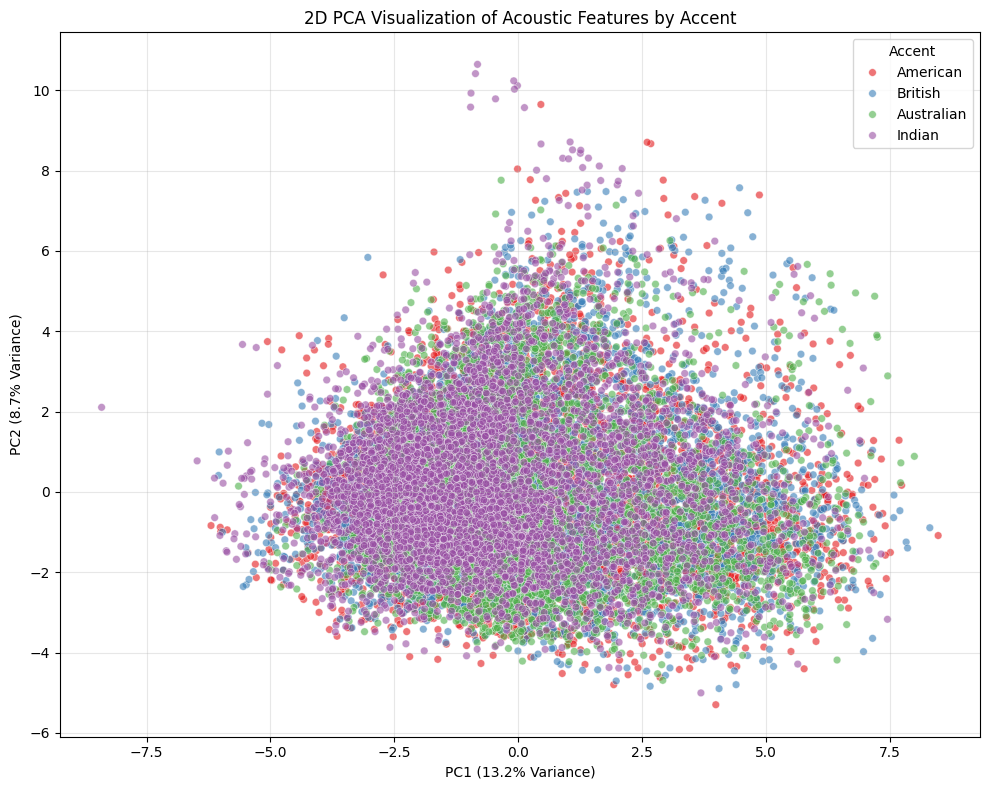

In [11]:
def visualize_features(X_features, y_labels):
    print("Standardizing features and calculating PCA...")
    
    # 1. Standardize the data (crucial before PCA so loud features don't dominate)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_features)
    
    # 2. Crush the 43 dimensions down to 2
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # 3. Put it in a DataFrame for easy plotting
    pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
    pca_df['Accent'] = y_labels
    
    # 4. Draw the scatter plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='Principal Component 1', 
        y='Principal Component 2', 
        hue='Accent', 
        palette='Set1', 
        data=pca_df, 
        alpha=0.6,
        s=30
    )
    
    plt.title("2D PCA Visualization of Acoustic Features by Accent")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
    plt.legend(title='Accent')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# RUN THE VISUALIZER
visualize_features(X_features, y)

#### Notes:
Possible notes from this section that we may want to add

## 5. Model Training

Training Logistic Regression...
Training Support Vector Machine (RBF Kernel)...
Training Complete!

       Logistic Regression Results
Accuracy: 38.6%

              precision    recall  f1-score   support

    American       0.35      0.23      0.27      1000
  Australian       0.38      0.43      0.40      1000
     British       0.36      0.33      0.34      1000
      Indian       0.43      0.57      0.49      1000

    accuracy                           0.39      4000
   macro avg       0.38      0.39      0.38      4000
weighted avg       0.38      0.39      0.38      4000



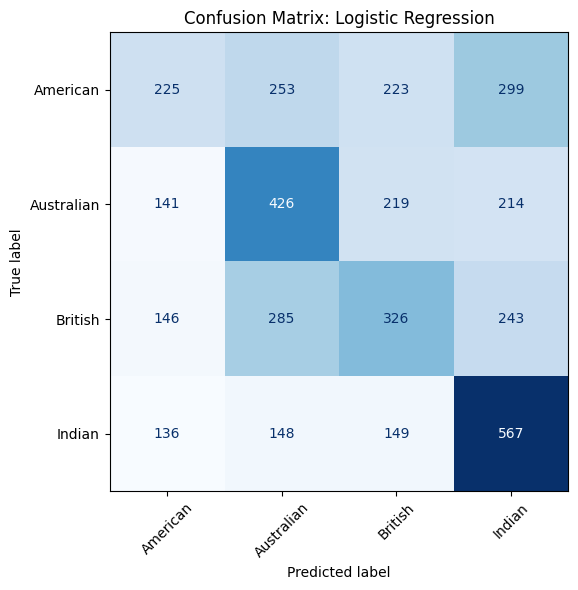

       Support Vector Machine Results
Accuracy: 64.5%

              precision    recall  f1-score   support

    American       0.58      0.51      0.55      1000
  Australian       0.72      0.70      0.71      1000
     British       0.63      0.65      0.64      1000
      Indian       0.64      0.71      0.68      1000

    accuracy                           0.65      4000
   macro avg       0.64      0.65      0.64      4000
weighted avg       0.64      0.65      0.64      4000



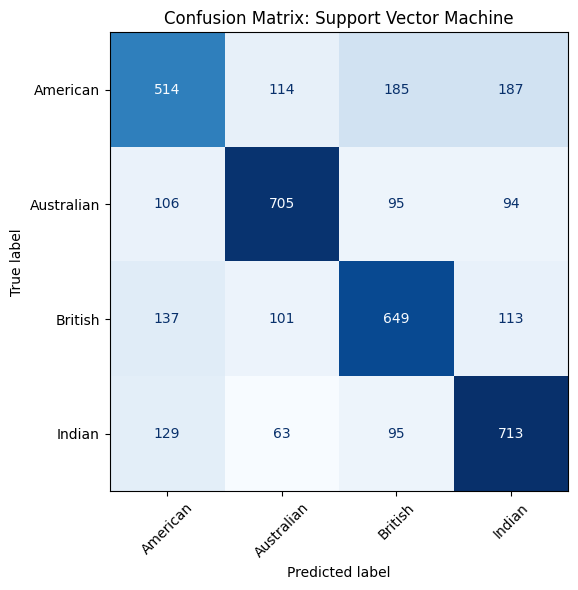

In [12]:
# 1. Split the data (80% for training, 20% for testing)
# 'stratify=y' ensures each accent is equally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scale the Data
# Critical for SVMs: makes sure frequency (large numbers) doesn't overpower energy (small numbers)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train Models
print("Training Logistic Regression...")
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

print("Training Support Vector Machine (RBF Kernel)...")
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("Training Complete!\n")

# 4. Evaluation Helper Function
def evaluate_and_plot(model, name, X_test_data, y_true):
    predictions = model.predict(X_test_data)
    acc = accuracy_score(y_true, predictions)
    
    print(f"========================================")
    print(f"       {name} Results")
    print(f"========================================")
    print(f"Accuracy: {acc * 100:.1f}%\n")
    print(classification_report(y_true, predictions))
    
    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true, predictions, cmap="Blues", ax=ax, colorbar=False
    )
    plt.title(f"Confusion Matrix: {name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5. Run Evaluations
evaluate_and_plot(log_model, "Logistic Regression", X_test_scaled, y_test)
evaluate_and_plot(svm_model, "Support Vector Machine", X_test_scaled, y_test)

In [13]:
# 1. Cargar el token secreto para una descarga rápida
load_dotenv()
hf_token = os.getenv("HF_TOKEN")

print("Loading WavLM Model (Downloading ~350MB)...")
# Usamos el token para que Hugging Face no nos ponga en la fila lenta
wavlm_model = WavLMModel.from_pretrained("microsoft/wavlm-base", token=hf_token)
wavlm_model.eval() 

def extract_wavlm_embeddings(audio_arrays):
    """Pasa el audio por la red neuronal para extraer los 768 features."""
    
    # ⚠️ PARA PRUEBAS: Solo procesaremos 200 audios en total (50 por acento)
    # Si intentas hacer los 4,000 en CPU, podría tardar horas.
    test_size = 200
    audio_subset = audio_arrays[:test_size]
    
    print(f"Extracting neural embeddings for {len(audio_subset)} audio clips...")
    print("Paciencia: Procesar redes neuronales en CPU es lento.")
    
    embeddings = []
    
    with torch.no_grad():
        for i, audio in enumerate(audio_subset):
            if (i + 1) % 10 == 0:
                print(f"Processed {i + 1} / {len(audio_subset)} clips...")
                
            input_values = torch.tensor(audio).unsqueeze(0).float()
            outputs = wavlm_model(input_values)
            
            # Extraer el vector de 768 dimensiones
            sentence_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
            embeddings.append(sentence_embedding)
            
    return np.array(embeddings)

# CORRER LA EXTRACCIÓN
X_neural = extract_wavlm_embeddings(X_raw)

# Cortamos también las etiquetas 'y' para que coincidan con los 200 audios procesados
y_neural_labels = y[:200]

print(f"\nNeural extraction complete!")
print(f"Final Data Matrix Shape: {X_neural.shape}")

Loading WavLM Model (Downloading ~350MB)...


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 50987.08it/s]


Extracting neural embeddings for 200 audio clips...
Paciencia: Procesar redes neuronales en CPU es lento.
Processed 10 / 200 clips...
Processed 20 / 200 clips...
Processed 30 / 200 clips...
Processed 40 / 200 clips...
Processed 50 / 200 clips...
Processed 60 / 200 clips...
Processed 70 / 200 clips...
Processed 80 / 200 clips...
Processed 90 / 200 clips...
Processed 100 / 200 clips...
Processed 110 / 200 clips...
Processed 120 / 200 clips...
Processed 130 / 200 clips...
Processed 140 / 200 clips...
Processed 150 / 200 clips...
Processed 160 / 200 clips...
Processed 170 / 200 clips...
Processed 180 / 200 clips...
Processed 190 / 200 clips...
Processed 200 / 200 clips...

Neural extraction complete!
Final Data Matrix Shape: (200, 768)


=== 1. Extracción Neuronal (Mini Prueba de 200 audios mezclados) ===
Progreso: 50 / 200 audios extraídos...
Progreso: 100 / 200 audios extraídos...
Progreso: 150 / 200 audios extraídos...
Progreso: 200 / 200 audios extraídos...

=== 2. Entrenamiento del Modelo SVM Neuronal ===
¡Entrenamiento completado!
       SVM (WavLM - Mini Prueba) Results
Accuracy: 52.5%

              precision    recall  f1-score   support

    American       0.44      0.40      0.42        10
  Australian       0.67      0.60      0.63        10
     British       0.42      0.50      0.45        10
      Indian       0.60      0.60      0.60        10

    accuracy                           0.53        40
   macro avg       0.53      0.53      0.53        40
weighted avg       0.53      0.53      0.53        40



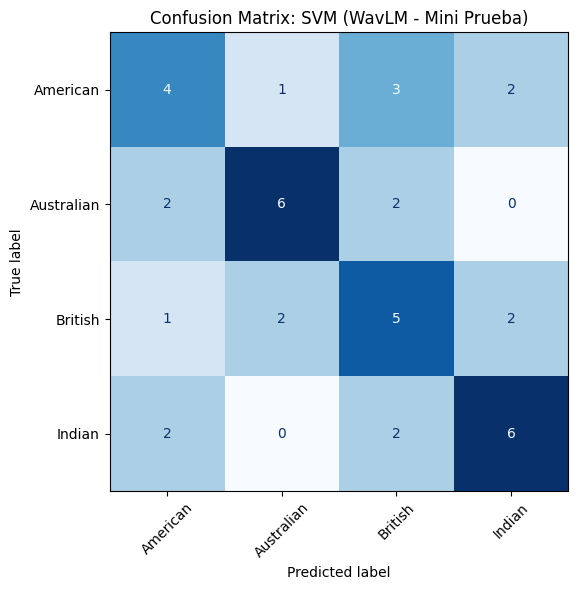

In [17]:
# 1. Crear un mini-dataset perfectamente mezclado (50 de cada acento = 200 en total)
# Usamos stratify=y para asegurar que toque exactamente la misma cantidad de cada país
_, X_raw_mini, _, y_mini = train_test_split(
    X_raw, y, test_size=200, random_state=42, stratify=y
)

print("=== 1. Extracción Neuronal (Mini Prueba de 200 audios mezclados) ===")
embeddings = []
with torch.no_grad():
    for i, audio in enumerate(X_raw_mini):
        if (i + 1) % 50 == 0:
            print(f"Progreso: {i + 1} / 200 audios extraídos...")
            
        input_values = torch.tensor(audio).unsqueeze(0).float()
        outputs = wavlm_model(input_values)
        sentence_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        embeddings.append(sentence_embedding)

X_neural_mini = np.array(embeddings)


print("\n=== 2. Entrenamiento del Modelo SVM Neuronal ===")
# 2. Dividir nuestra mini-muestra (80% entrenar, 20% evaluar)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_neural_mini, y_mini, test_size=0.2, random_state=42, stratify=y_mini
)

# 3. Escalar las 768 dimensiones
scaler_n = StandardScaler()
X_train_scaled_n = scaler_n.fit_transform(X_train_n)
X_test_scaled_n = scaler_n.transform(X_test_n)

# 4. Entrenar
svm_neural_model = SVC(kernel='rbf', random_state=42)
svm_neural_model.fit(X_train_scaled_n, y_train_n)
print("¡Entrenamiento completado!")

# 5. Evaluar (usando la función que creaste en el paso 11)
evaluate_and_plot(svm_neural_model, "SVM (WavLM - Mini Prueba)", X_test_scaled_n, y_test_n)

#### Notes:
Possible notes from this section that we may want to add

## 6. Evaluation & Analysis

In [14]:
# Code to display pretty tables and all of that

# different code blocks per display

All our ideas, of way we got the results we got and all of that

## 7. Conclusion

jhbvsdcuiysvic